In [1]:
# edge_stgnn_forecast.py
# End-to-end edge-based spatio-temporal GNN for bicycle flow forecasting.
# Requirements: python>=3.9, torch, pandas, numpy, networkx, matplotlib
# pip install torch pandas numpy networkx matplotlib

from __future__ import annotations
from typing import List, Dict, Tuple, Set, Any


import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import os


import matplotlib.pyplot as plt
import networkx as nx
from scripts.preprocessing import Config, NetworkConfig
from scripts import models, preprocessing, features, training, visualisation



e:\Python\Bicycle_Traffic_Flow_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("torch", torch.__version__)
print("cuda available?", torch.cuda.is_available())
print("cuda runtime:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # synchronous CUDA; precise traceback
torch.cuda.empty_cache()

torch 2.8.0+cu128
cuda available? True
cuda runtime: 12.8
device count: 1


In [3]:
# ----------------------------
# 1) Network definition
# ----------------------------

# Nodes
NODES = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# Example coordinates in (x, y). Replace with your true values (meters or canvas units).
POS = {
    'A': (0, 10), 'B': (5, 10),
    'C': (0, 7),  'D': (5, 7),
    'E': (0, 4), 'F': (5, 4), 'G': (9, 4),
    'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
    'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
    'P': (5, -5)
}

# Physical undirected links
PHYSICAL_EDGES = [
    ('A','B'),        # no sensor
    ('A','C'),
    ('C','E'),
    ('B','D'),
    ('D','F'),        # no sensor
    ('C','D'),        # no sensor
    ('D','G'),        # no sensor
    ('G','K'),
    ('K','O'),
    ('H','I'),
    ('I','J'),
    ('J','K'),
    ('K','L'),
    ('E','I'),
    ('F','J'),
    ('J','N'),        # no sensor
    ('N','P'),
    ('I','M'),
    ('M','N'),        # no sensor
    ('N','O')         # no sensor
]

# Edges without sensors (undirected listing). Both directions will be masked.
NO_SENSOR_UNDIR = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('D','F'), ('J','N'), ('C','D')}

# Map each (sensor_id|element_name) to its BASE direction (u->v).
# count_in goes to (u->v); count_out goes to (v->u).
SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
    "TUD_SBX01|Line 0": ("D", "B"),
    "TUD_SPX18|Line 0": ("A", "C"),
    "TUD_SBX22|Line 0": ("E", "C"),
    "TUD_SBXN6A|Line 2": ("F", "J"),
    "TUD_SBXN6A|Line 0": ("J", "K"),
    "TUD_SPX23|Line 0": ("I", "E"),
    "TUD_SBX25|Line 2": ("I", "H"),
    "TUD_SBX26|Line 0": ("I", "M"),
    "TUD_SPX24|Line 0": ("J", "I"),
    "TUD_SBX07-MULTI|Line 1": ("G", "K"),
    "TUD_SBX07-MULTI|Line 2": ("K", "L"),
    "TUD_SBX07-MULTI|Line 3": ("O", "K"),
    "TUD_SBXN13|Line 0": ("P", "N"),
}

DIRECTED_EDGES = preprocessing.undir_to_dir(PHYSICAL_EDGES)

EDGE_INDEX = {e:i for i,e in enumerate(DIRECTED_EDGES)}
INDEX_EDGE = {i:e for e,i in EDGE_INDEX.items()}

A_line = preprocessing.build_line_graph_adjacency(DIRECTED_EDGES, allow_uturn=False)
A_hat = preprocessing.normalize_adjacency(A_line)

network_cfg = NetworkConfig(
    nodes=NODES,
    pos=POS,
    physical_edges=PHYSICAL_EDGES,
    no_sensor_undir=NO_SENSOR_UNDIR,
    sensor_to_edge=SENSOR_TO_EDGE,
    directed_edges=DIRECTED_EDGES,
    edge_index=EDGE_INDEX,
    index_edge=INDEX_EDGE,
    a_line=A_line,
    a_hat=A_hat
)

In [4]:
# ----------------------------
# 2) Helpers: build directed edges & line-graph adjacency
# ----------------------------

# def undir_to_dir(undirected_edges: List[Tuple[str,str]]) -> List[Tuple[str,str]]:
#     dirs = []
#     for u,v in undirected_edges:
#         dirs.append((u,v))
#         dirs.append((v,u))
#     return dirs

# DIRECTED_EDGES = undir_to_dir(PHYSICAL_EDGES)

# EDGE_INDEX = {e:i for i,e in enumerate(DIRECTED_EDGES)}
# INDEX_EDGE = {i:e for e,i in EDGE_INDEX.items()}

# def is_no_sensor_dir(e: Tuple[str,str]) -> bool:
#     u,v = e
#     return (u,v) in NO_SENSOR_UNDIR or (v,u) in NO_SENSOR_UNDIR

# def build_line_graph_adjacency(directed_edges: List[Tuple[str,str]], allow_uturn=False) -> np.ndarray:
#     """
#     L(G) nodes = directed edges of original graph.
#     Connect e1=(a->b) to e2=(c->d) if b==c and (optionally) d!=a to avoid U-turns.
#     """
#     E = len(directed_edges)
#     A = np.zeros((E,E), dtype=np.float32)
#     for i,(a,b) in enumerate(directed_edges):
#         for j,(c,d) in enumerate(directed_edges):
#             if b == c and (allow_uturn or d != a):
#                 A[i,j] = 1.0
#     # add self-loops (common in GCN normalisation)
#     np.fill_diagonal(A, 1.0)
#     return A

# A_line = build_line_graph_adjacency(DIRECTED_EDGES, allow_uturn=False)

# def normalize_adjacency(A: np.ndarray) -> np.ndarray:
#     """ Ā = D^{-1/2} A D^{-1/2} """
#     d = A.sum(axis=1)
#     d_inv_sqrt = np.power(d, -0.5, where=(d>0))
#     D_inv_sqrt = np.diag(d_inv_sqrt)
#     return (D_inv_sqrt @ A @ D_inv_sqrt).astype(np.float32)

# A_hat = normalize_adjacency(A_line)


# def _fmt_time(secs: float) -> str:
#     secs = max(0, int(secs))
#     m, s = divmod(secs, 60)
#     h, m = divmod(m, 60)
#     return f"{h:d}:{m:02d}:{s:02d}"

# def spike_aware_loss(pred, target, mask, tau, alpha=1.5, beta=0.3):
#     # base MAE, upweighted for large targets
#     w = 1.0 + alpha * (target / tau).clamp(min=0)
#     base = (pred - target).abs()
#     num = (base * w * mask).sum()
#     den = (w * mask).sum().clamp_min(1.0)
#     loss_base = num / den
#     # slope term (match first differences)
#     d_pred = pred[:, 1:, :] - pred[:, :-1, :]
#     d_tgt  = target[:, 1:, :] - target[:, :-1, :]
#     d_mask = mask[:, 1:, :] * mask[:, :-1, :]
#     loss_slope = (d_mask * (d_pred - d_tgt).abs()).sum() / d_mask.sum().clamp_min(1.0)
#     return loss_base + beta * loss_slope

In [5]:
# ----------------------------
# 3) Data loading & preprocessing
# ----------------------------

# @dataclass
# class Config:
#     time_granularity: str = "5min"  # resample bin
#     H_in: int = 12                  # 12*5min = 1 hour history
#     H_out: int = 12                 # forecast next hour
#     batch_size: int = 64
#     lr: float = 1e-3
#     max_epochs: int = 100
#     patience: int = 15
#     device: str = "cuda" if torch.cuda.is_available() else "cpu"
#     seed: int = 42
#     use_exog: bool = True


# def dedupe_within_bucket(df: pd.DataFrame, bucket: str) -> pd.DataFrame:
#     # df has: timestamp, sensor_key, count_in, count_out, created_at (optional), end_time (optional)
#     df = df.copy()
#     df['bucket'] = df['timestamp'].dt.floor(bucket)

#     sort_cols = ['sensor_key', 'bucket']
#     # Prefer created_at if present, else end_time, else timestamp
#     if 'created_at' in df.columns:
#         sort_cols.append('created_at')
#     elif 'end_time' in df.columns:
#         sort_cols.append('end_time')
#     else:
#         sort_cols.append('timestamp')

#     df = df.sort_values(sort_cols)
#     # keep='last' -> keeps the most recent record per sensor_key per bucket
#     df = df.drop_duplicates(subset=['sensor_key', 'bucket'], keep='last')

#     df['timestamp'] = df['bucket']
#     return df.drop(columns='bucket')


# def set_seed(seed: int):
#     random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


# def parse_smartcamera_csv(paths: List[str]) -> pd.DataFrame:
#     """
#     Returns a tidy DataFrame with:
#       timestamp (naive datetime), sensor_key, count_in, count_out  (floats)
#     """
#     frames = []
#     for p in paths:
#         df = pd.read_csv(p)
#         # datetimes
#         for col in ['start_time','end_time','created_at']:
#             if col in df.columns:
#                 df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
#         # choose start_time as the bin anchor
#         ts = df['start_time']
#         if getattr(ts.dt, 'tz', None) is not None:
#             ts = ts.dt.tz_convert(None)
#         df['timestamp'] = ts

#         df['sensor_key'] = df['sensor_id'].astype(str) + "|" + df['element_name'].astype(str)
#         # numeric, NaN -> 0
#         df['count_in']  = pd.to_numeric(df.get('count_in', 0), errors='coerce').fillna(0.0)
#         df['count_out'] = pd.to_numeric(df.get('count_out',0), errors='coerce').fillna(0.0)

#         frames.append(df[['timestamp','sensor_key','count_in','count_out']])
#     return pd.concat(frames, ignore_index=True)

# def build_edge_time_matrix(all_df: pd.DataFrame,
#                            sensor_to_base_dir: Dict[str, Tuple[str,str]],
#                            config: Config) -> Tuple[pd.DatetimeIndex, np.ndarray, np.ndarray]:
#     """
#     Make X[T,E] by routing count_in to (u->v) and count_out to (v->u)
#     according to sensor_to_base_dir[sensor_key] = (u,v).
#     Also builds a mask M[T,E] that is 1 only where targets are observed.
#     """
#     all_df = dedupe_within_bucket(all_df, config.time_granularity)
#     df = all_df[all_df['sensor_key'].isin(sensor_to_base_dir.keys())].copy()
#     if df.empty:
#         raise ValueError("No sensor_key in CSV matched SENSOR_TO_EDGE mapping.")

#     # Map base direction (u,v)
#     uv = df['sensor_key'].map(sensor_to_base_dir)
#     df['u'] = uv.apply(lambda t: t[0])
#     df['v'] = uv.apply(lambda t: t[1])

#     # Long form for IN: edge = (u->v)
#     din = df[['timestamp','u','v','count_in']].rename(
#         columns={'u':'src','v':'dst','count_in':'count'})
#     # Long form for OUT: edge = (v->u)
#     dout = df[['timestamp','u','v','count_out']].rename(
#         columns={'u':'dst','v':'src','count_out':'count'})

#     long = pd.concat([din, dout], ignore_index=True)
#     # Pack tuple so we can pivot
#     long['edge'] = list(zip(long['src'], long['dst']))

#     # Sum within bins per directed edge
#     piv = (long
#            .pivot_table(index='timestamp', columns='edge', values='count', aggfunc='sum')
#            .sort_index()
#            .resample(config.time_granularity).sum()
#            .fillna(0.0))

#     # Ensure we have every directed edge as a column (zeros if absent)
#     cols = [tuple(e) for e in DIRECTED_EDGES]
#     for e in cols:
#         if e not in piv.columns:
#             piv[e] = 0.0
#     piv = piv[cols]

#     # Mask: 0 for edges that **never** have sensors; 1 elsewhere
#     observed_mask = pd.DataFrame(1.0, index=piv.index, columns=piv.columns, dtype=float)
#     for e in DIRECTED_EDGES:
#         if is_no_sensor_dir(e):
#             observed_mask[e] = 0.0

#     # If you want to downweight sporadic missing bins for edges that *do* have sensors,
#     # you can set mask=0 where both in and out were NaN before fill, but for counts
#     # we usually keep zeros as valid 'no crossings' observations.

#     times = piv.index
#     X = piv.values.astype(np.float32)           # [T,E]
#     M = observed_mask.values.astype(np.float32) # [T,E]
#     return times, X, M


# def add_exogenous(times: pd.DatetimeIndex, E: int, config: Config, weather_df: Optional[pd.DataFrame]=None) -> np.ndarray:
#     """
#     Returns exogenous features repeated across edges: [T, E, F_exog]
#     """
#     # Ensure DatetimeIndex
#     times = pd.DatetimeIndex(times)
#     T = len(times)

#     # --- time-of-day (seconds) ---
#     sec_in_day = 24 * 3600
#     tod_seconds = (
#         times.hour.to_numpy() * 3600
#         + times.minute.to_numpy() * 60
#         + times.second.to_numpy()
#     )

#     tod_angle = 2 * np.pi * tod_seconds / sec_in_day
#     tod_sin = np.sin(tod_angle).reshape(T, 1).astype(np.float32)
#     tod_cos = np.cos(tod_angle).reshape(T, 1).astype(np.float32)

#     # --- day-of-week (0=Mon) ---
#     dow = times.dayofweek.to_numpy()
#     dow_angle = 2 * np.pi * dow / 7.0
#     dow_sin = np.sin(dow_angle).reshape(T, 1).astype(np.float32)
#     dow_cos = np.cos(dow_angle).reshape(T, 1).astype(np.float32)

#     feats = [tod_sin, tod_cos, dow_sin, dow_cos]

#     # --- optional weather aligned to 'times' ---
#     if weather_df is not None:
#         W = (weather_df
#              .reindex(times)
#              .fillna(method='ffill')
#              .fillna(method='bfill'))
#         Wv = W.to_numpy(dtype=np.float32, copy=False)
#         feats.append(Wv)

#     exog_t = np.concatenate(feats, axis=1)            # [T, F_exog]
#     exog = np.repeat(exog_t[:, None, :], E, axis=1)   # [T, E, F_exog]
#     return exog


# def add_edge_lags(X: np.ndarray, lags_steps=(12*24, 12*24*7)) -> np.ndarray:
#     """
#     Create edge-specific lag features from raw counts.
#     X: [T, E] counts
#     lags_steps: tuple of integer steps (for 5-min bins: 12*24=1 day, 12*24*7=1 week)
#     returns: [T, E, L] where L=len(lags_steps)
#     """
#     T, E = X.shape
#     feats = []
#     for L in lags_steps:
#         lag = np.zeros((T, E), dtype=np.float32)   # zeros for the first L rows (no past)
#         if L < T:
#             lag[L:] = X[:-L]
#         feats.append(lag[..., None])                # [T,E,1]
#     return np.concatenate(feats, axis=2)            # [T,E,L]

# def steps_for_hours(granularity: str, hours: int) -> int:
#     step = pd.Timedelta(granularity)          # e.g., '5min' or '15min'
#     return int(pd.Timedelta(f'{hours}h') / step)

In [6]:
# ----------------------------
# 4) Dataset with sliding windows
# ----------------------------

# class WindowedEdgeDataset(Dataset):
#     def __init__(self, X: np.ndarray, M: np.ndarray, exog: Optional[np.ndarray], H_in: int, H_out: int):
#         """
#         X: [T, E] main feature (flow); exog: [T, E, F_exog] or None
#         """
#         assert X.ndim == 2
#         self.X = X
#         self.M = M
#         self.exog = exog
#         self.H_in = H_in
#         self.H_out = H_out
#         self.T, self.E = X.shape
#         self.N = self.T - (H_in + H_out) + 1
#         if self.N <= 0:
#             raise ValueError("Not enough time steps for given H_in/H_out.")

#     def __len__(self): return self.N

#     def __getitem__(self, idx):
#         t0 = idx
#         t1 = idx + self.H_in
#         t2 = t1 + self.H_out
#         x_hist = self.X[t0:t1, :]                         # [H_in, E]
#         y_fut  = self.X[t1:t2, :]                         # [H_out, E]
#         m_fut  = self.M[t1:t2, :]                         # [H_out, E]
#         if self.exog is not None:
#             ex_hist = self.exog[t0:t1, :, :]              # [H_in, E, F_exog]
#             ex_fut  = self.exog[t1:t2, :, :]
#             x = np.concatenate([x_hist[:,:,None], ex_hist], axis=2)  # [H_in, E, 1+F_exog]
#             x_future_feats = ex_fut                                      # for decoder-free TCN we can pass future exog, or ignore
#         else:
#             x = x_hist[:,:,None]                          # [H_in, E, 1]
#             x_future_feats = None
#         return {
#             "x": torch.from_numpy(x.astype(np.float32)),                 # [H_in, E, F]
#             "y": torch.from_numpy(y_fut.astype(np.float32)),             # [H_out, E]
#             "mask": torch.from_numpy(m_fut.astype(np.float32)),          # [H_out, E]
#             "x_future_feats": (None if x_future_feats is None else torch.from_numpy(x_future_feats.astype(np.float32)))
#         }

In [7]:
# ----------------------------
# 5) ST-GCN-like model (GCN over line-graph + temporal conv)
# ----------------------------

# class GCNLayer(nn.Module):
#     def __init__(self, F_in: int, F_out: int, A_hat: torch.Tensor, dropout=0.0):
#         super().__init__()
#         # make sure dtype is float32 at registration time
#         self.register_buffer('A_hat', A_hat.to(dtype=torch.float32))
#         self.lin = nn.Linear(F_in, F_out, bias=True)
#         self.act = nn.ReLU()
#         self.do = nn.Dropout(dropout)

#     def forward(self, X):  # X: [B,T,E,F_in]
#         # ensure the buffer lives on the same device as activations
#         A = self.A_hat.to(X.device, non_blocking=True)   # <— important
#         Xw = self.lin(X)                                 # [B,T,E,F_out]
#         Xprop = torch.einsum('ij,btjf->btif', A, Xw)     # [B,T,E,F_out]
#         return self.do(self.act(Xprop))


# class TemporalConv(nn.Module):
#     def __init__(self, F_in: int, F_out: int, k: int=3, dilation: int=1, dropout=0.0):
#         super().__init__()
#         padding = (k-1)*dilation
#         self.conv = nn.Conv2d(in_channels=F_in, out_channels=F_out,
#                               kernel_size=(k,1), dilation=(dilation,1), padding=(padding,0))
#         self.act = nn.ReLU()
#         self.do = nn.Dropout(dropout)
#     def forward(self, X):  # X: [B,T,E,F] -> make channels=F, height=T, width=E
#         B,T,E,F = X.shape
#         Xp = X.permute(0,3,1,2).contiguous()     # [B,F,T,E]
#         Y = self.conv(Xp)                      # causal-ish with left padding
#         Y = Y[:,:,:T,:]                        # trim to keep length
#         Y = self.act(Y)
#         Y = self.do(Y)
#         return Y.permute(0,2,3,1)             # [B,T,E,F_out]

# class STBlock(nn.Module):
#     def __init__(self, F_in: int, F_hidden: int, A_hat: torch.Tensor, dropout=0.1, dilation=1):
#         super().__init__()
#         self.temp1 = TemporalConv(F_in, F_hidden, k=3, dilation=dilation, dropout=dropout)
#         self.gcn   = GCNLayer(F_hidden, F_hidden, A_hat, dropout=dropout)
#         self.temp2 = TemporalConv(F_hidden, F_hidden, k=3, dilation=1, dropout=dropout)
#         self.resid = nn.Conv2d(F_in, F_hidden, kernel_size=(1,1))
#     def forward(self, X):  # [B,T,E,F_in]
#         R = self.resid(X.permute(0,3,1,2))    # [B,F_hidden,T,E]
#         R = R.permute(0,2,3,1)
#         out = self.temp1(X)
#         out = self.gcn(out)
#         out = self.temp2(out)
#         return out + R


# class EdgeSTGNN(nn.Module):
#     def __init__(self, E: int, F_in: int, H_out: int, A_hat: np.ndarray, nblocks=2, hidden=32, dropout=0.1):
#         super().__init__()
#         A_hat = sanitize_and_row_normalize_A(A_hat)
#         A = torch.from_numpy(A_hat).to(torch.float32)         # <— convert numpy -> torch
#         self.register_buffer('A_hat', A)
        
#         blocks = []
#         dil = 1
#         Fin = F_in
#         for _ in range(nblocks):
#             blocks.append(STBlock(Fin, hidden, self.A_hat, dropout=dropout, dilation=dil))
#             Fin = hidden
#             dil *= 2
#         self.blocks = nn.ModuleList(blocks)
#         self.head = nn.Sequential(
#             nn.Conv2d(hidden, hidden, kernel_size=(1,1)),
#             nn.ReLU(),
#             nn.Conv2d(hidden, H_out, kernel_size=(1,1))   # output per future step
#         )
#     def forward(self, X):  # X: [B,T_in,E,F_in]
#         out = X
#         for blk in self.blocks:
#             out = blk(out)
#         out = out.permute(0,3,1,2)            # [B,F,T,E]
#         out = self.head(out)                  # [B,H_out,T,E]
#         # we only use the last time point of hidden timeline after convs (aligned to input length)
#         out = out[:,:,-1,:]                   # [B,H_out,E]
#         out = nn.functional.softplus(out)
#         return out


In [8]:
# ----------------------------
# 6) Training & evaluation
# ----------------------------


# def masked_mae(pred, target, mask, eps=1e-8):
#     # pred/target: [B,H,E]; mask: [B,H,E]
#     diff = (pred - target).abs()
#     num = (diff * mask).sum()
#     den = mask.sum() + eps
#     return num / den


# def masked_mse(pred, target, mask, eps=1e-8):
#     mask = (mask > 0).to(pred.dtype)
#     diff2 = (pred - target) ** 2
#     num = (diff2 * mask).sum()
#     den = mask.sum().clamp_min(1.0)
#     return num / den


# def sanitize_and_row_normalize_A(A_hat_np: np.ndarray) -> np.ndarray:
#     A = np.array(A_hat_np, dtype=np.float32, copy=True)

#     # Remove non-finite, then add self-loops (guarantees >=1 degree)
#     A[~np.isfinite(A)] = 0.0
#     np.fill_diagonal(A, A.diagonal() + 1.0)

#     # Row-normalize with floor to avoid div-by-zero
#     rowsum = A.sum(axis=1, keepdims=True)
#     rowsum = np.where(rowsum < 1e-6, 1.0, rowsum)
#     A = A / rowsum

#     # Final clean
#     A[~np.isfinite(A)] = 0.0
#     return A


# def train_model(model, loaders, config: Config):
#     device = config.device
#     model.to(device)
#     opt = optim.Adam(model.parameters(), lr=config.lr)
#     best = {"val": float("inf"), "state": None, "epoch": -1}
#     patience = config.patience

#     hist = {"epoch": [], "train": [], "val": []}

#     for epoch in tqdm(range(1, config.max_epochs + 1), desc="Epochs", leave=True):
#         model.train()
#         tot = 0.0

#         for batch in loaders["train"]:
#             x = batch["x"].to(device, non_blocking=True)              # [B,H_in,E,F]
#             y = batch["y"].to(device, non_blocking=True)              # [B,H_out,E]
#             m = batch["mask"].to(device, non_blocking=True)           # [B,H_out,E]
            
#             # quick checks
#             for name, t in [("x", x), ("y", y), ("mask", m)]:
#                 if not torch.isfinite(t).all():
#                     bad = (~torch.isfinite(t)).sum().item()
#                     raise RuntimeError(f"{name} has {bad} non-finite values")

#             opt.zero_grad()
#             yhat = model(x)
#             if not torch.isfinite(yhat).all():
#                 raise RuntimeError("model output contains NaN/Inf")
#             loss = masked_mae(yhat, y, m)
#             if not torch.isfinite(loss):
#                 print("Non-finite loss. Stats:",
#                     f"y min/max = {float(y.min()):.3f}/{float(y.max()):.3f},",
#                     f"mask sum = {float(m.sum()):.1f}")
#                 raise RuntimeError("Loss is NaN/Inf")
#             loss.backward()
#             opt.step()
#             tot += loss.item()
#         train_mae = tot / max(1,len(loaders["train"]))
        
#         model.eval()
#         with torch.no_grad():
#             def eval_on(split):
#                 tot = 0.0
#                 for batch in loaders[split]:
#                     x = batch["x"].to(device)
#                     y = batch["y"].to(device)
#                     m = batch["mask"].to(device)
#                     yhat = model(x)
#                     tot += masked_mae(yhat, y, m).item()
#                 return tot / max(1,len(loaders[split]))
#             val_mae = eval_on("val")
#         print(f"epoch {epoch:03d}  train_mae={tot/max(1,len(loaders['train'])):.4f}  val_mae={val_mae:.4f}")

#         hist["epoch"].append(epoch)
#         hist["train"].append(train_mae)
#         hist["val"].append(val_mae)

#         if val_mae < best["val"] - 1e-6:
#             best = {"val": val_mae, "state": model.state_dict(), "epoch": epoch}
#             patience = config.patience
#         else:
#             patience -= 1
#             if patience <= 0:
#                 print(f"early stop at epoch {epoch}, best epoch {best['epoch']} val_mae={best['val']:.4f}")
#                 break
#     if best["state"] is not None:
#         model.load_state_dict(best["state"])
#     model.history = hist
#     return model

# def evaluate(model, loader, device) -> Dict[str,float]:
#     model.eval()
#     mae_sum = rmse_sum = m_sum = 0.0
#     with torch.no_grad():
#         for batch in loader:
#             x = batch["x"].to(device, non_blocking=True)
#             y = batch["y"].to(device, non_blocking=True)
#             m = batch["mask"].to(device, non_blocking=True)
#             yhat = model(x)
#             err = (yhat - y)
#             mae_sum += (err.abs() * m).sum().item()
#             rmse_sum += ((err**2)*m).sum().item()
#             m_sum += m.sum().item()
#     mae = mae_sum / (m_sum + 1e-8)
#     rmse = math.sqrt(rmse_sum / (m_sum + 1e-8))
#     return {"MAE": mae, "RMSE": rmse}

In [9]:
# ----------------------------
# 7) Visualisation
# ----------------------------

# def draw_network_flows(edge_values: Dict[Tuple[str,str], float], title: str=""):
#     G = nx.DiGraph()
#     G.add_nodes_from(NODES)
#     for u,v in DIRECTED_EDGES:
#         G.add_edge(u,v)
#     plt.figure(figsize=(8,6))
#     widths = []
#     for (u,v) in G.edges():
#         val = edge_values.get((u,v), 0.0)
#         widths.append(1.0 + 0.06*max(0.0, val))
#     nx.draw_networkx_nodes(G, POS, node_size=400, node_color='white', edgecolors='black')
#     nx.draw_networkx_labels(G, POS, font_size=10)
#     nx.draw_networkx_edges(G, POS, width=widths, arrows=True, arrowstyle='-|>', arrowsize=12)
#     plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()

In [10]:
# ----------------------------
# 8) Main: wiring everything
# ----------------------------

# Notebook-friendly runner: no argparse, returns artifacts you can reuse.


def run_experiment_in_notebook(
    csv_paths,
    weather_csv=None,
    cfg=None,
    partial_policy="dedupe",   # "dedupe" (keep last per bucket) or "sum" (sum partials)
    print_every=True
):
    """
    csv_paths: list of CSV file paths for your sensors
    weather_csv: optional CSV with weather; must have a 'timestamp' column
    cfg: Config() object; if None, uses defaults from the script
    partial_policy: "dedupe" to drop repeated lines per bucket, or "sum" to sum partial reads
    returns: dict with model, loaders, metrics, times, predictions, etc.
    """
    # 0) config & seed
    if cfg is None:
        cfg = Config()
    features.set_seed(cfg.seed)

    # 1) load raw sensor data (count_in / count_out preserved)
    raw = preprocessing.parse_smartcamera_csv(csv_paths)

    # 2) handle repeated reports in a bin
    if partial_policy == "dedupe":
        raw = preprocessing.dedupe_within_bucket(raw, cfg.time_granularity)
    # elif partial_policy == "sum":
        # raw = collapse_partials_within_bucket(raw, cfg.time_granularity)
    else:
        raise ValueError("partial_policy must be 'dedupe' or 'sum'.")

    # 3) build edge-time matrix (routes count_in to (u->v) and count_out to (v->u))
    times, X, M = preprocessing.build_edge_time_matrix(raw, cfg, network_cfg)  # X:[T,E], M:[T,E]
    T, E = X.shape

    # 4) optional exogenous features
    exog = None
    if cfg.use_exog:
        weather_df = None
        if weather_csv:
            w = pd.read_csv(weather_csv, parse_dates=['timestamp'])
            w = (w.set_index('timestamp')
                   .sort_index()
                   .resample(cfg.time_granularity)
                   .mean())
            weather_df = w.select_dtypes(include=[np.number])
        exog = features.add_exogenous(times, E, cfg, weather_df)

    # # --- add edge-specific lag features ---
    # edge_lags = add_edge_lags(X, lags_steps=(12*24, 12*24*7, 12*24*14))  # day & week lags, [T,E,2]
    # exog = edge_lags if exog is None else np.concatenate([exog, edge_lags], axis=2)

    print("exog shape:", None if exog is None else exog.shape)  # expect [T, E, 4(+weather)+2]
    # sample = artifacts["loaders"]["train"].dataset[0]["x"].shape[-1]
    # print("feature count passed to model (F):", sample)

    # 5) chronological split
    n = len(times)
    n_train = int(0.6*n); n_val = int(0.2*n)
    slices = {
        "train": slice(0, n_train),
        "val":   slice(n_train, n_train+n_val),
        "test":  slice(n_train+n_val, n)
    }

    loaders = {}
    for split, s in slices.items():
        ds = preprocessing.WindowedEdgeDataset(
            X[s], M[s],
            exog[s] if exog is not None else None,
            cfg.H_in, cfg.H_out
        )
        loaders[split] = DataLoader(
            ds,
            batch_size=cfg.batch_size,
            shuffle=(split == "train"),
            drop_last=True,
            pin_memory=(cfg.device.startswith("cuda"))
        )

    # 6) model
    F_in = 1 + (exog.shape[-1] if exog is not None else 0)
    model = models.EdgeSTGNN(E=E, F_in=F_in, H_out=cfg.H_out, A_hat=A_hat, nblocks=2, hidden=32, dropout=0.1)

    # 7) train
    if print_every:
        print(f"Device: {cfg.device} | Samples: {n} | Edges (directed): {E}")
    model = training.train_model(model, loaders, cfg)

    # 8) evaluate
    metrics = training.evaluate(model, loaders["test"], cfg.device)
    if print_every:
        print("Test metrics:", metrics)

    # 9) one visual prediction (first batch, first horizon step)
    batch = next(iter(loaders["test"]))
    with torch.no_grad():
        yhat = model(batch["x"].to(cfg.device)).cpu().numpy()  # [B,H_out,E]
    pred_edge_step0 = {INDEX_EDGE[i]: float(yhat[0, 0, i]) for i in range(yhat.shape[-1])}

    # Optionally draw (inline)
    visualisation.draw_network_flows(pred_edge_step0, title="Predicted flows (first forecast step)", network_cfg = network_cfg)

    return {
        "model": model,
        "cfg": cfg,
        "loaders": loaders,
        "times": times,
        "X": X,
        "M": M,
        "exog": exog,
        "metrics_test": metrics,
        "yhat_example": yhat,           # numpy array [B,H_out,E]
        "pred_edge_step0": pred_edge_step0
    }


exog shape: (11521, 40, 4)
Device: cuda | Samples: 11521 | Edges (directed): 40


Epochs:   5%|▌         | 1/20 [00:09<02:57,  9.33s/it]

epoch 001  train_mae=1.1070  val_mae=1.1428


Epochs:  10%|█         | 2/20 [00:17<02:36,  8.69s/it]

epoch 002  train_mae=0.8827  val_mae=0.8493


...

Epochs:  95%|█████████▌| 19/20 [02:35<00:08,  8.25s/it]

epoch 019  train_mae=0.5908  val_mae=0.7047


Epochs: 100%|██████████| 20/20 [02:44<00:00,  8.22s/it]

epoch 020  train_mae=0.5898  val_mae=0.7001


Test metrics: {'MAE': 0.7340441692288896, 'RMSE': 2.300147822110937}


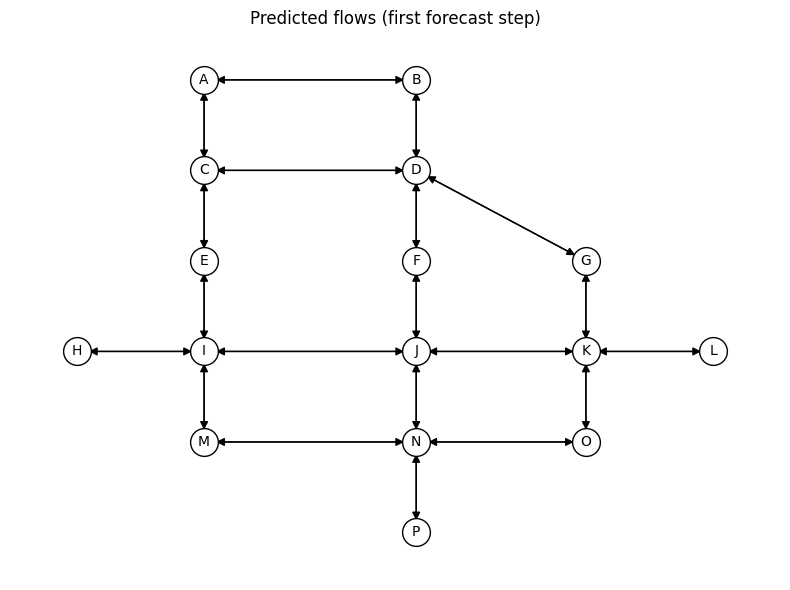

Test: {'MAE': 0.7340441692288896, 'RMSE': 2.300147822110937}
('A', 'B') 3.522115719079011e-07
('B', 'A') 3.5221191296841425e-07
('A', 'C') 3.5221125926909735e-07
('C', 'A') 3.522115719079011e-07
('C', 'E') 3.522115719079011e-07
('E', 'C') 3.522115719079011e-07
('B', 'D') 3.522115719079011e-07
('D', 'B') 3.5221191296841425e-07
('D', 'F') 3.522115719079011e-07
('F', 'D') 3.522115719079011e-07


In [11]:
# Ensure inline plotting in notebooks
%matplotlib inline

# 1) Fill in your mapping and coordinates BEFORE running this cell:
#    - SENSOR_TO_EDGE  (base directions)
#    - POS             (exact coordinates)

csv_paths = [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    "data/smartcameras_line--2025-02-01T03-01-00--2025-03-01T03-01-00--tud_project--bvtmix.csv",
    "data/smartcameras_line--2025-03-01T03-01-00--2025-04-01T03-01-00--tud_project--a93fyx.csv",
    "data/smartcameras_line--2025-04-01T03-01-00--2025-05-01T03-01-00--tud_project--henvbs.csv"
]
weather_csv = None  # or a path like "/content/data/weather_5min_2025.csv"

time_granularity = "15min"
H_in = features.steps_for_hours(time_granularity, 24)          # hours in the past
H_out = features.steps_for_hours(time_granularity, 3)         # hours in the future

cfg = Config(
    time_granularity = time_granularity,
    H_in = H_in,
    H_out = H_out,
    batch_size=64,
    lr=1e-4,
    max_epochs=20,
    patience=8,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    use_exog=True
)

artifacts = run_experiment_in_notebook(
    csv_paths=csv_paths,
    weather_csv=weather_csv,
    cfg=cfg,
    partial_policy="dedupe",   # or "sum" if your device sends partials within a bin
    print_every=True
)

# Access results:
print("Test:", artifacts["metrics_test"])
# Example: inspect one predicted vector for the first sample & first horizon
E = len(DIRECTED_EDGES)
first_pred = artifacts["yhat_example"][0,0,:].reshape(E)
for i, val in enumerate(first_pred[:10]):  # show first 10 edges
    print(INDEX_EDGE[i], float(val))


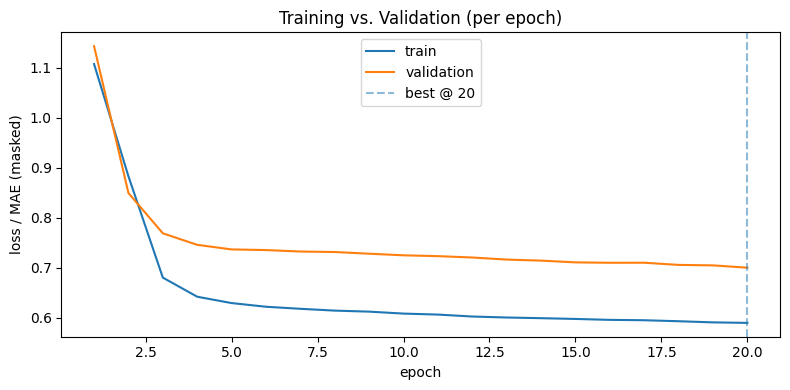

[1.1070069479492475, 0.8826720034176448, 0.6802531764754709, 0.6420482191837059, 0.629377470826203, 0.6220296975576652, 0.6179378952057857, 0.6143024206723807, 0.6122549243693082, 0.6083482402675556, 0.6063775771631384, 0.6024939192915862, 0.6005319022345093, 0.5991756817642248, 0.5976546280226618, 0.5958197954690682, 0.5950774606668724, 0.5930913998833243, 0.5907959119891221, 0.5897817808502125]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

h = getattr(artifacts["model"], "history", None)
if not h:
    raise RuntimeError("No history found. Re-run training after replacing train_model.")

epochs = np.array(h["epoch"])
train  = np.array(h["train"])
val    = np.array(h["val"])
best_ix = int(np.argmin(val))

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label="train")
plt.plot(epochs, val,   label="validation")
plt.axvline(epochs[best_ix], linestyle="--", alpha=0.5, label=f"best @ {epochs[best_ix]}")
plt.title("Training vs. Validation (per epoch)")
plt.xlabel("epoch")
plt.ylabel("loss / MAE (masked)")
plt.legend()
plt.tight_layout()
plt.show()

print(h["train"])

In [13]:
# pull from your earlier 'artifacts' dict
model = artifacts["model"]
cfg = artifacts["cfg"]
times = artifacts["times"]
test_ds = artifacts["loaders"]["test"].dataset

# reconstruct where TEST starts in the global timeline (60/20/20 split)
n = len(times)
n_train = int(0.6 * n)
n_val   = int(0.2 * n)
test_start = n_train + n_val

H_in, H_out = cfg.H_in, cfg.H_out
E = len(DIRECTED_EDGES)

# make an eval loader that does NOT drop the final, partial batch
eval_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=cfg.device.startswith("cuda")
)

preds, trues, masks = [], [], []

model.eval()
with torch.no_grad():
    for batch in eval_loader:
        x = batch["x"].to(cfg.device, non_blocking=True)
        y = batch["y"].to(cfg.device, non_blocking=True)
        m = batch["mask"].to(cfg.device, non_blocking=True)
        yhat = model(x)                              # [B, H_out, E]
        preds.append(yhat.cpu().numpy())
        trues.append(y.cpu().numpy())
        masks.append(m.cpu().numpy())

YH = np.concatenate(preds, axis=0)  # [N_eff, H_out, E]
Y  = np.concatenate(trues, axis=0)  # [N_eff, H_out, E]
M  = np.concatenate(masks, axis=0)  # [N_eff, H_out, E]
N_eff = YH.shape[0]

# build a tidy table with timestamp, horizon, edge (u->v), pred/true/observed
records = []
for i in range(N_eff):
    t_start = test_start + H_in + i             # absolute index where this forecast window starts
    for h in range(H_out):
        t_abs = t_start + h
        ts = times[t_abs]
        for e_idx, (u, v) in enumerate(DIRECTED_EDGES):
            records.append({
                "timestamp": ts,
                "h": h,                         # 0 = first step ahead
                "u": u,
                "v": v,
                "edge": f"{u}->{v}",
                "pred": float(YH[i, h, e_idx]),
                "true": float(Y[i, h, e_idx]),
                "observed": bool(M[i, h, e_idx] > 0.5),
            })

df_pred = (pd.DataFrame.from_records(records)
          .sort_values(["timestamp", "h", "u", "v"])
          .reset_index(drop=True))

# show the full table (can be large)
df_pred


,timestamp,h,u,v,edge,pred,true,observed
0,2025-04-08 03:00:00,0,A,B,A->B,3.522116e-07,0.0,False
1,2025-04-08 03:00:00,0,A,C,A->C,3.522113e-07,0.0,True
2,2025-04-08 03:00:00,0,B,A,B->A,3.522119e-07,0.0,False
3,2025-04-08 03:00:00,0,B,D,B->D,3.522116e-07,0.0,True
4,2025-04-08 03:00:00,0,C,A,C->A,3.522116e-07,0.0,True
...,...,...,...,...,...,...,...,...
1055035,2025-05-01 03:00:00,11,N,O,N->O,5.742958e-15,0.0,False
1055036,2025-05-01 03:00:00,11,N,P,N->P,5.742958e-15,0.0,True
1055037,2025-05-01 03:00:00,11,O,K,O->K,5.742936e-15,0.0,True
1055038,2025-05-01 03:00:00,11,O,N,O->N,5.742936e-15,0.0,False


In [14]:
# === Pre-flight checks (run before the training cell) ===
from pathlib import Path
import pandas as pd
import numpy as np

# 0) File exists?
for p in [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv"
]:
    if not Path(p).exists():
        raise FileNotFoundError(f"CSV not found: {p}")
print("✓ CSV found")

# 1) Peek at the CSV schema quickly
peek = pd.read_csv(
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    nrows=5
)
print("Columns:", list(peek.columns))

required_cols = {"sensor_id","element_name","start_time","count_in","count_out"}
missing = required_cols - set(peek.columns)
if missing:
    raise ValueError(f"CSV missing required columns: {missing}")
print("✓ Required columns present")

# 2) Mapping coverage sanity check (quick sample of keys)
raw_sample = pd.read_csv(
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    usecols=["sensor_id","element_name"], nrows=5000
)
raw_sample["sensor_key"] = raw_sample["sensor_id"].astype(str) + "|" + raw_sample["element_name"].astype(str)
all_keys = set(raw_sample["sensor_key"].unique())
mapped_keys = set(SENSOR_TO_EDGE.keys())

unmapped = sorted(all_keys - mapped_keys)
print(f"Mapped keys in dict: {len(mapped_keys)} | Keys seen in sample: {len(all_keys)}")
if unmapped:
    print("⚠ Unmapped sensor keys (first 20):", unmapped[:20])
    # Not fatal, but you’ll get zeros on those edges; add them to SENSOR_TO_EDGE when possible.
else:
    print("✓ All sampled keys are mapped")

# 3) Coordinates present?
if not POS:
    raise ValueError("POS (node coordinates) is empty. Fill POS before training.")
unknown_nodes = [n for n in NODES if n not in POS]
if unknown_nodes:
    raise ValueError(f"Missing coordinates for nodes: {unknown_nodes}")
print("✓ Coordinates loaded for all nodes")

# 4) Presence-based mask function in use?
try:
    preprocessing.build_edge_time_matrix  # function must exist
    print("✓ build_edge_time_matrix is defined")
except NameError:
    raise RuntimeError("build_edge_time_matrix is not defined in this notebook session.")

print("Pre-flight checks passed.")


✓ CSV found
Columns: ['pkey_id', 'created_at', 'sensor_id', 'start_time', 'end_time', 'count_in', 'count_out', 'element_id', 'element_name']
✓ Required columns present
Mapped keys in dict: 13 | Keys seen in sample: 32
⚠ Unmapped sensor keys (first 20): ['TUD_SBX07-MULTI|Line 4', 'TUD_SBX07-MULTI|Line 5', 'TUD_SBX07A|Line  1', 'TUD_SBX07A|Line 2', 'TUD_SBX07A|Line 3', 'TUD_SBX07|Line 0', 'TUD_SBX07|Line 2', 'TUD_SBX07|Line 3', 'TUD_SBX26|Line 2', 'TUD_SBX27|Line 0', 'TUD_SBXN8A|Line 0', 'TUD_SBXN8B|Line 0', 'TUD_SBXN9A|Line 0', 'TUD_SBXN9B|Line 0', 'TUD_SBXS12|Line 0', 'TUD_SBXS13|Line 0', 'TUD_SPX14|Line 0', 'TUD_SPX15|Line 0', 'TUD_SPXS06_IO|Line 0']
✓ Coordinates loaded for all nodes
✓ build_edge_time_matrix is defined
Pre-flight checks passed.


B->D — 2025-04-24  MAE=2.108, RMSE=5.291  (on observed bins)


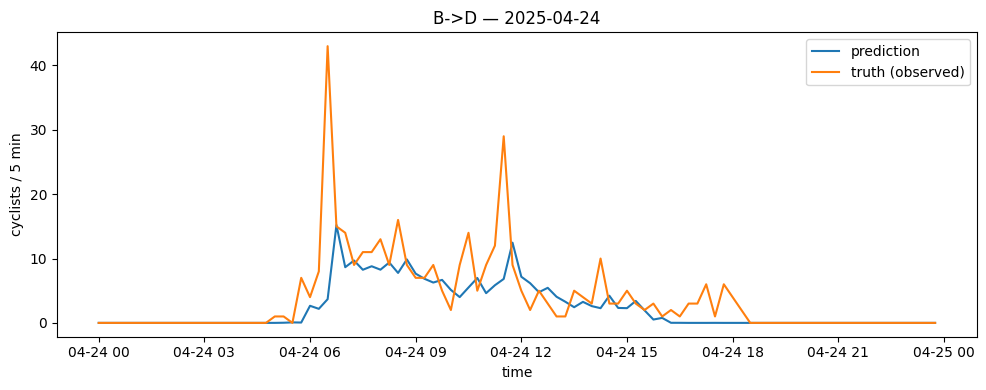

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # pick the edge and the calendar day you want to visualise
# edge_uv = ('B','D')            # <-- change me
# day_str = '2025-01-30'         # <-- change me (YYYY-MM-DD)

# edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
# day = pd.to_datetime(day_str).date()

# # filter to that edge & day
# sel = df_pred[(df_pred['edge'] == edge_str) &
#               (df_pred['timestamp'].dt.date == day)].copy()

# # keep only bins with ground truth (observed)
# sel_true = sel[sel['observed']].copy()

# # sort & drop duplicates (shouldn’t exist, but safe)
# sel = sel.sort_values(['timestamp','h'])
# sel_true = sel_true.sort_values(['timestamp','h'])

# # build time series (one point per timestamp)
# ts_pred = sel.groupby('timestamp', as_index=True)['pred'].mean()
# ts_true = sel_true.groupby('timestamp', as_index=True)['true'].mean()

edge_uv = ('B','D')           # <-- change me
day_str = '2025-04-24'        # <-- change me (YYYY-MM-DD)

edge_str = f'{edge_uv[0]}->{edge_uv[1]}'
sel = df_pred[(df_pred['edge']==edge_str) &
              (df_pred['timestamp'].dt.date==pd.to_datetime(day_str).date())]

# keep the *smallest* horizon per timestamp
sel = (sel.sort_values(['timestamp','h'])
           .drop_duplicates(['timestamp','edge'], keep='first'))

ts_pred = sel.set_index('timestamp')['pred']
ts_true = sel[sel['observed']].set_index('timestamp')['true']


# compute metrics on common timestamps with truth
common_idx = ts_true.index.intersection(ts_pred.index)
mae = float(np.mean(np.abs(ts_pred.reindex(common_idx) - ts_true.reindex(common_idx))))
rmse = float(np.sqrt(np.mean((ts_pred.reindex(common_idx) - ts_true.reindex(common_idx))**2)))
print(f"{edge_str} — {day_str}  MAE={mae:.3f}, RMSE={rmse:.3f}  (on observed bins)")

# plot
plt.figure(figsize=(10,4))
plt.plot(ts_pred.index, ts_pred.values, label='prediction')
plt.plot(ts_true.index, ts_true.values, label='truth (observed)')
plt.title(f"{edge_str} — {day_str}")
plt.xlabel("time")
plt.ylabel("cyclists / 5 min")
plt.legend()
plt.tight_layout()
plt.show()


B->D — farthest horizon only — 2025-04-24:  MAE=3.047, RMSE=6.524


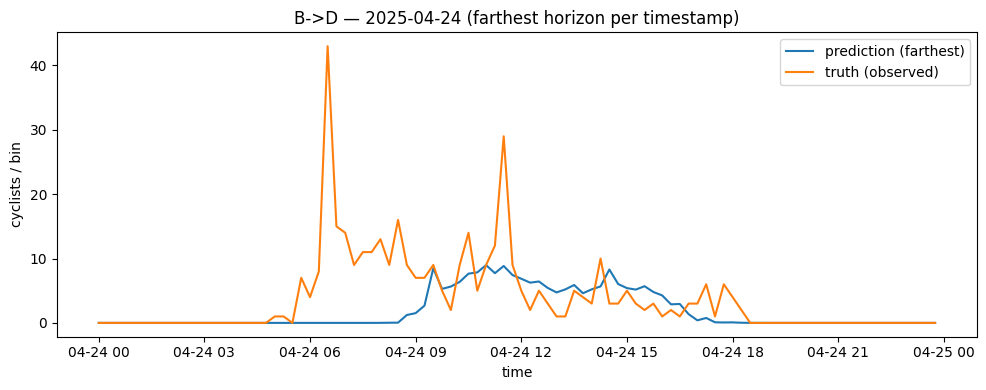

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

edge_uv = ('B','D')            # pick your edge
day_str = '2025-04-24'         # pick the calendar day to visualise (YYYY-MM-DD)

edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
day = pd.to_datetime(day_str).date()

# 1) filter the edge & day
sel = df_pred[(df_pred['edge'] == edge_str) &
              (df_pred['timestamp'].dt.date == day)].copy()

# 2) keep the farthest forecast per (timestamp, edge) -> largest h
far = (sel.sort_values(['timestamp','h'])
          .drop_duplicates(['timestamp','edge'], keep='last'))

# 3) build time series and compare to truth (only where observed)
ts_pred_far = far.set_index('timestamp')['pred']
ts_true     = far[far['observed']].set_index('timestamp')['true']  # ground truth only where present

# metrics on common timestamps with truth
idx = ts_true.index.intersection(ts_pred_far.index)
mae_far  = float(np.mean(np.abs(ts_pred_far.reindex(idx) - ts_true.reindex(idx))))
rmse_far = float(np.sqrt(np.mean((ts_pred_far.reindex(idx) - ts_true.reindex(idx))**2)))
print(f"{edge_str} — farthest horizon only — {day_str}:  MAE={mae_far:.3f}, RMSE={rmse_far:.3f}")

# 4) plot
plt.figure(figsize=(10,4))
plt.plot(ts_pred_far.index, ts_pred_far.values, label='prediction (farthest)')
plt.plot(ts_true.index,     ts_true.values,     label='truth (observed)')
plt.title(f"{edge_str} — {day_str} (farthest horizon per timestamp)")
plt.xlabel("time"); plt.ylabel("cyclists / bin"); plt.legend(); plt.tight_layout(); plt.show()


Per-edge values at 2025-04-24 12:00:00 (horizon=closest)


,u,v,edge,observed,true,pred,abs_err
751927,D,B,D->B,True,10.0,7.236786,2.763214
751923,B,D,B->D,True,5.0,7.170510,2.170510
751942,J,F,J->F,True,2.0,5.413325,3.413325
751934,F,J,F->J,True,4.0,4.049572,0.049572
751924,C,A,C->A,True,5.0,3.076300,1.923700
751949,K,O,K->O,True,0.0,2.675002,2.675002
751921,A,C,A->C,True,2.0,2.588329,0.588329
751931,E,C,E->C,True,0.0,1.983750,1.983750
751948,K,L,K->L,True,3.0,1.951192,1.048808
751941,I,M,I->M,True,0.0,1.794626,1.794626


Top 15 by TRUE (observed) at 2025-04-24 12:00:00


,u,v,edge,true,pred,abs_err
751927,D,B,D->B,10.0,7.236786,2.763214
751923,B,D,B->D,5.0,7.170510,2.170510
751924,C,A,C->A,5.0,3.076300,1.923700
751934,F,J,F->J,4.0,4.049572,0.049572
751948,K,L,K->L,3.0,1.951192,1.048808
751938,I,E,I->E,3.0,1.458427,1.541573
751921,A,C,A->C,2.0,2.588329,0.588329
751942,J,F,J->F,2.0,5.413325,3.413325
751932,E,I,E->I,1.0,0.554303,0.445697
751926,C,E,C->E,1.0,1.645295,0.645295


C:\Temp\Raf\ipykernel_6708\2728302451.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmapname)


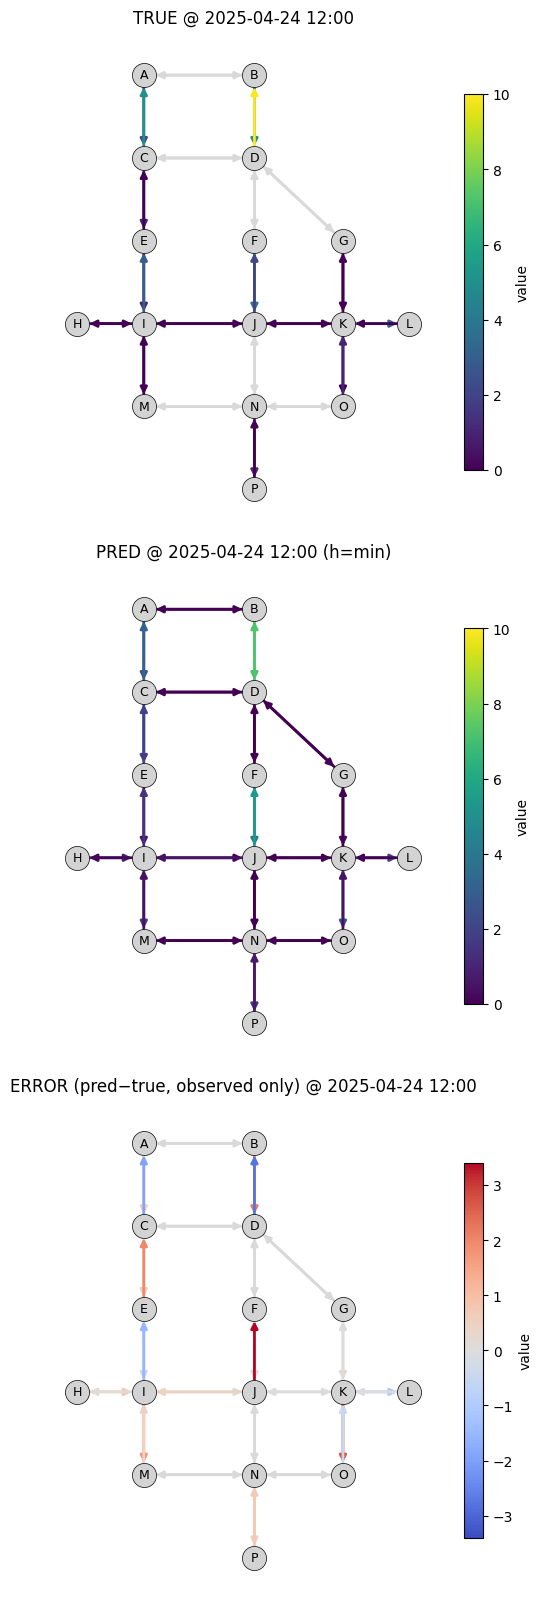

In [17]:
# === Day summary tables + network picture (peaks) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
from matplotlib import cm, colors as mcolors
# ---- CONFIGURE ----
day_str   = '2025-04-24'   # day to inspect (YYYY-MM-DD)
time_str  = '12:00'        # local time within that day
use_closest = True         # horizon: True -> smallest h; False -> largest h
top_k = 15                 # table: show top-K edges by true or pred at the moment

# ---------- helpers ----------
def _select_by_h(df_edge_time, use_closest=True):
    if use_closest:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='first'))
    else:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='last'))

def _mae_rmse_on_observed(df_edge_day):
    g = df_edge_day[df_edge_day['observed']]
    if g.empty:
        return np.nan, np.nan
    err = g['pred'] - g['true']
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    return mae, rmse

def _edge_peak_tables(df_day_sel: pd.DataFrame) -> pd.DataFrame:
    # 0) ensure 'edge' column exists (fallback from u/v)
    if 'edge' not in df_day_sel.columns:
        df_day_sel = df_day_sel.copy()
        df_day_sel['edge'] = df_day_sel['u'].astype(str) + '->' + df_day_sel['v'].astype(str)

    # 1) TRUE peaks (use observed bins only)
    obs = df_day_sel[df_day_sel.get('observed', True)].copy()

    if obs.empty:
        # build an empty but correctly-typed table
        cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak',
                'abs_err_at_true_peak','peak_pred','t_pred_peak','true_at_pred_peak',
                'abs_err_at_pred_peak','mae_day','rmse_day','observed_bins','total_bins','observed_frac']
        return pd.DataFrame(columns=cols)

    obs_sorted = obs.sort_values(['edge','true'], ascending=[True, False])
    true_peaks = (obs_sorted.groupby('edge', as_index=False)
                           .first()[['edge','u','v','timestamp','true']]
                           .rename(columns={'timestamp':'t_true_peak','true':'peak_true'}))

    # predicted value at the time of the TRUE peak
    pred_at_true_peak = (df_day_sel[['edge','timestamp','pred']]
                         .merge(true_peaks[['edge','t_true_peak']],
                                left_on=['edge','timestamp'],
                                right_on=['edge','t_true_peak'],
                                how='right')
                         .rename(columns={'pred':'pred_at_true_peak'})
                         [['edge','pred_at_true_peak']])

    # 2) PRED peaks (on selected horizon rows)
    sel_sorted = df_day_sel.sort_values(['edge','pred'], ascending=[True, False])
    pred_peaks = (sel_sorted.groupby('edge', as_index=False)
                           .first()[['edge','timestamp','pred','true','observed']]
                           .rename(columns={'timestamp':'t_pred_peak','pred':'peak_pred',
                                            'true':'true_at_pred_peak','observed':'obs_at_pred_peak'}))

    # 3) Per-edge day stats (MAE/RMSE on observed bins only)
    stats_rows = []
    for e, g in df_day_sel.groupby('edge'):
        g_obs = g[g.get('observed', True)]
        if g_obs.empty:
            mae = rmse = np.nan
            obs_cnt = 0
        else:
            err = (g_obs['pred'] - g_obs['true']).to_numpy()
            mae = np.abs(err).mean()
            rmse = np.sqrt((err**2).mean())
            obs_cnt = int(g_obs.shape[0])
        tot_cnt = int(g.shape[0])
        stats_rows.append({
            'edge': e, 'mae_day': mae, 'rmse_day': rmse,
            'observed_bins': obs_cnt, 'total_bins': tot_cnt,
            'observed_frac': (obs_cnt / max(1, tot_cnt))
        })
    day_stats = pd.DataFrame(stats_rows)

    # 4) Join everything on a *column* 'edge'
    tbl = (true_peaks
           .merge(pred_at_true_peak, on='edge', how='left')
           .merge(pred_peaks,       on='edge', how='left')
           .merge(day_stats,        on='edge', how='left'))

    # 5) Absolute errors at peak times
    tbl['abs_err_at_true_peak'] = (tbl['pred_at_true_peak'] - tbl['peak_true']).abs()
    tbl['abs_err_at_pred_peak'] = (tbl['peak_pred'] - tbl['true_at_pred_peak']).abs()

    # nice ordering
    cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak','abs_err_at_true_peak',
            'peak_pred','t_pred_peak','true_at_pred_peak','abs_err_at_pred_peak',
            'mae_day','rmse_day','observed_bins','total_bins','observed_frac']
    return tbl[cols].sort_values('peak_true', ascending=False).reset_index(drop=True)



def _plot_network_values(POS, edges, values, title, vmin=None, vmax=None, cmapname='viridis', show_arrows=True, ax=None):
    if ax is None: ax = plt.gca()
    G = nx.DiGraph(); G.add_nodes_from(POS.keys()); G.add_edges_from(edges)
    edgelist = list(edges)

    vals = np.array([values.get((u,v), np.nan) for (u,v) in edgelist], float)
    # choose scale
    if vmin is None: vmin = float(np.nanmin(vals)) if np.isfinite(vals).any() else 0.0
    if vmax is None: vmax = float(np.nanmax(vals)) if np.isfinite(vals).any() else 1.0
    if not np.isfinite(vmin): vmin = 0.0
    if (not np.isfinite(vmax)) or vmax <= vmin: vmax = vmin + 1.0

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmapname)
    # colors: NaNs -> light gray
    colors = [cmap(norm(v)) if np.isfinite(v) else (0.85,0.85,0.85,1.0) for v in vals]
    # # widths: based on |value| so negatives still visible (error panel)
    # scale = vmax - vmin if vmax > vmin else 1.0
    # widths = 1.0 + 4.0 * (np.abs(vals - (vmin + scale/2.0)) / (scale/2.0))
    # widths = np.clip(widths, 0.5, 5.0)
    widths = np.full_like(vals, 2.0, dtype=float)


    ax.set_title(title)
    nx.draw_networkx_nodes(G, POS, node_size=300, node_color='lightgray', edgecolors='k', linewidths=0.5, ax=ax)
    nx.draw_networkx_edges(G, POS, edgelist=edgelist, width=widths,
                           edge_color=colors, arrows=show_arrows,
                           arrowstyle='-|>', arrowsize=10, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=9, ax=ax)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    ax.figure.colorbar(sm, ax=ax, shrink=0.75).set_label('value')
    ax.set_axis_off()
    return sm


# # ------------------- main -------------------
# # Select day + deduplicate horizons
# day = pd.to_datetime(day_str).date()
# df_day = df_pred[df_pred['timestamp'].dt.date == day].copy()
# df_day = _select_by_h(df_day, use_closest=use_closest)

# # Summary tables
# edge_tbl = _edge_peak_tables(df_day)

# # Show top-K edges by true daily peak
# print(f"Daily peak summary (top {top_k}) — {day_str}  (horizon={'closest' if use_closest else 'farthest'})")
# display(edge_tbl.head(top_k))

# # Network totals table (when whole-network truth peaks)
# obs = df_day[df_day['observed']]
# net_by_ts = (obs.groupby('timestamp')[['true','pred']]
#                .sum().rename(columns={'true':'true_total','pred':'pred_total'})
#                .sort_index())
# if not net_by_ts.empty:
#     idx_peak = net_by_ts['true_total'].idxmax()
#     print("\nNetwork totals — top rows (true_total desc):")
#     display(net_by_ts.sort_values('true_total', ascending=False).head(10))
#     print(f"Peak network truth at: {idx_peak}  value={float(net_by_ts.loc[idx_peak,'true_total']):.1f}")

# # Build edge->daily peak dicts (truth/pred) for plotting
# # Truth: daily max of true over observed bins; Pred: daily max of pred (selected horizon)
# edge_true_peaks = {}
# edge_pred_peaks = {}
# for (u,v), g in df_day.groupby(['u','v']):
#     g_obs = g[g['observed']]
#     if not g_obs.empty:
#         edge_true_peaks[(u,v)] = float(g_obs['true'].max())
#     else:
#         edge_true_peaks[(u,v)] = 0.0
#     edge_pred_peaks[(u,v)] = float(g['pred'].max()) if not g.empty else 0.0

# # Common color scale so plots are comparable
# all_max = max(max(edge_true_peaks.values() or [1.0]), max(edge_pred_peaks.values() or [1.0]))
# all_max = all_max if all_max > 0 else 1.0

# # Plots
# fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
# _plot_network_values(POS, DIRECTED_EDGES, edge_true_peaks,
#                      f"Daily peak TRUE per directed edge — {day_str}",
#                      vmin=0, vmax=all_max, ax=axs[0])
# _plot_network_values(POS, DIRECTED_EDGES, edge_pred_peaks,
#                      f"Daily peak PRED per directed edge — {day_str}",
#                      vmin=0, vmax=all_max, ax=axs[1])
# plt.show()


# # Optional: save artifacts
# edge_tbl.to_csv(f"edge_daily_peaks_{day_str.replace('-','')}.csv", index=False)
# plt.savefig(f"network_daily_peaks_{day_str.replace('-','')}.png", dpi=180, bbox_inches='tight')
# print("Saved:",
#       f"edge_daily_peaks_{day_str.replace('-','')}.csv",
#       f"network_daily_peaks_{day_str.replace('-','')}.png")

# ---------- main ----------
# 1) pick the closest timestamp to the requested moment on that day
t_req = pd.Timestamp(f"{day_str} {time_str}")
day = t_req.date()

df_day = df_pred[df_pred['timestamp'].dt.date == day].copy()
if df_day.empty:
    raise ValueError(f"No predictions for day {day_str} in df_pred.")

ts_np   = df_day['timestamp'].values.astype('datetime64[ns]')
t_req_np = np.datetime64(t_req)
idx = np.argmin(np.abs(ts_np - t_req_np))
t_sel = pd.Timestamp(ts_np[idx])
if t_sel != t_req:
    print(f"Using closest timestamp on {day_str}: requested {t_req.time()}, selected {pd.Timestamp(t_sel).time()}")

# 2) select rows at that timestamp and resolve horizon duplicates
df_t = df_day[df_day['timestamp'] == t_sel].copy()
if 'edge' not in df_t.columns:
    df_t['edge'] = df_t['u'].astype(str) + '->' + df_t['v'].astype(str)
df_t = _select_by_h(df_t, use_closest=use_closest)

# 3) build per-edge dicts
edge_true = {}
edge_pred = {}
edge_err  = {}
for (u,v), g in df_t.groupby(['u','v']):
    pred = float(g['pred'].iloc[0])
    edge_pred[(u,v)] = pred
    if bool(g['observed'].iloc[0]):
        tru = float(g['true'].iloc[0])
    else:
        tru = np.nan  # no truth available at that instant
    edge_true[(u,v)] = tru
    edge_err[(u,v)]  = (pred - tru) if np.isfinite(tru) else np.nan

# 4) summary tables at the moment
tbl = (df_t[['u','v','edge','observed','true','pred']]
       .assign(abs_err=lambda d: np.where(d['observed'], (d['pred']-d['true']).abs(), np.nan))
       .sort_values(['observed','pred'], ascending=[False, False]))
print(f"Per-edge values at {pd.Timestamp(t_sel)} (horizon={'closest' if use_closest else 'farthest'})")
display(tbl.head(top_k))

# top by TRUE (observed only)
tbl_true = (df_t[df_t['observed']][['u','v','edge','true','pred']]
            .assign(abs_err=lambda d: (d['pred']-d['true']).abs())
            .sort_values('true', ascending=False))
print(f"Top {top_k} by TRUE (observed) at {pd.Timestamp(t_sel)}")
display(tbl_true.head(top_k))

# 5) draw network: TRUE / PRED / ERROR
vmax_tp = np.nanmax([*edge_true.values(), *edge_pred.values(), 1.0])
vmax_tp = vmax_tp if np.isfinite(vmax_tp) and vmax_tp > 0 else 1.0
err_vals = np.array([v for v in edge_err.values() if np.isfinite(v)])
err_max = float(np.nanmax(np.abs(err_vals))) if err_vals.size else 1.0

fig, axs = plt.subplots(3, 1, figsize=(5,16), constrained_layout=True)
_plot_network_values(POS, DIRECTED_EDGES, edge_true,
                     f"TRUE @ {pd.Timestamp(t_sel).strftime('%Y-%m-%d %H:%M')}",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[0])
_plot_network_values(POS, DIRECTED_EDGES, edge_pred,
                     f"PRED @ {pd.Timestamp(t_sel).strftime('%Y-%m-%d %H:%M')} (h={'min' if use_closest else 'max'})",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[1])
_plot_network_values(POS, DIRECTED_EDGES, edge_err,
                     f"ERROR (pred−true, observed only) @ {pd.Timestamp(t_sel).strftime('%Y-%m-%d %H:%M')}",
                     vmin=-err_max, vmax=err_max, cmapname='coolwarm', ax=axs[2])
plt.show()

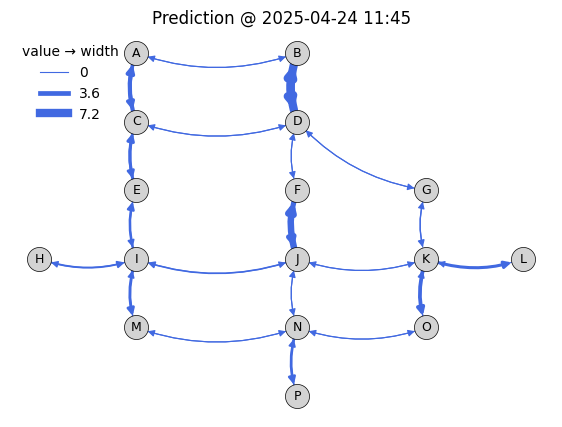

In [18]:
import numpy as np, matplotlib.pyplot as plt, networkx as nx
from matplotlib.lines import Line2D

def plot_network_thickness_only(
    POS, edges, values, title="",
    base_color="#355C7D",            # constant edge color
    min_w=0.8, max_w=6.0,            # thickness range (points)
    vmin=None, vmax=None,            # optional manual scale for values
    use_abs=False,                   # True -> width ∝ |value|
    offset_rad=0.18,                 # curvature for opposite directions
    show_arrows=True,
    ax=None
):
    """
    POS: dict node -> (x,y)
    edges: iterable of (u,v)
    values: dict {(u,v): value}
    """
    if ax is None: ax = plt.gca()

    # Graph
    G = nx.DiGraph()
    G.add_nodes_from(POS.keys())
    G.add_edges_from(edges)

    # Values per edge (NaN for missing)
    edgelist = list(edges)
    vals = np.array([values.get((u,v), np.nan) for (u,v) in edgelist], dtype=float)

    # Scale for widths
    if use_abs:
        data = np.abs(vals)
    else:
        data = vals

    finite = np.isfinite(data)
    if vmin is None: vmin = float(np.nanmin(data)) if finite.any() else 0.0
    if vmax is None: vmax = float(np.nanmax(data)) if finite.any() else 1.0
    if not np.isfinite(vmin): vmin = 0.0
    if (not np.isfinite(vmax)) or vmax <= vmin: vmax = vmin + 1.0

    # Normalize -> widths
    scale = max(vmax - vmin, 1e-9)
    norm = np.clip((data - vmin) / scale, 0.0, 1.0)
    widths = min_w + (max_w - min_w) * norm
    widths[~finite] = min_w * 0.6  # for NaNs

    # Determine which edges are reciprocal to offset them
    e_set = set(edgelist)
    paired_key = set((min(u,v), max(u,v)) for (u,v) in edgelist if (v,u) in e_set)

    def rad_for(u, v):
        key = (min(u,v), max(u,v))
        if key not in paired_key:
            return 0.0
        # consistent split: smaller label -> +rad, larger -> -rad
        return +offset_rad if u < v else -offset_rad

    # Draw
    ax.set_title(title)
    nx.draw_networkx_nodes(G, POS, node_size=300, node_color='lightgray',
                           edgecolors='k', linewidths=0.5, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=9, ax=ax)

    # draw per edge so we can set per-edge width and curvature
    for (w, (u, v), val) in zip(widths, edgelist, vals):
        cs = f"arc3,rad={rad_for(u, v)}"
        color = base_color if np.isfinite(val) else "#BBBBBB"   # constant color; gray if NaN
        nx.draw_networkx_edges(
            G, POS, edgelist=[(u, v)], width=float(w),
            edge_color=color, arrows=show_arrows,
            arrowstyle='-|>', arrowsize=10, connectionstyle=cs, ax=ax
        )

    ax.set_axis_off()

    # width legend (optional)
    w_low, w_mid, w_hi = min_w, (min_w+max_w)/2, max_w
    legend_lines = [
        Line2D([0], [0], color=base_color, lw=w_low,  label=f"{vmin:.2g}"),
        Line2D([0], [0], color=base_color, lw=w_mid,  label=f"{vmin + 0.5*(vmax-vmin):.2g}"),
        Line2D([0], [0], color=base_color, lw=w_hi,   label=f"{vmax:.2g}"),
    ]
    ax.legend(handles=legend_lines, frameon=False, title="value → width", loc="upper left")

    return {"vmin": vmin, "vmax": vmax}

# ---------- main ----------
# Example: snapshot at a chosen moment (edge_pred from your earlier cell)
fig, ax = plt.subplots(1, 1, figsize=(7,5))
plot_network_thickness_only(
    POS, DIRECTED_EDGES, edge_pred,
    title="Prediction @ 2025-04-24 11:45",
    base_color="royalblue", min_w=0.8, max_w=6.0,
    vmin=0, vmax=None,       # fix vmin=0 for counts
    use_abs=False,           # width ∝ value
    offset_rad=0.18,         # separate u→v and v→u
    ax=ax
)
plt.show()
